# Quantitative Asset Forecasting — Gold & Stock/ETF Portfolio Modeling

This notebook builds a compact **quant-style research pipeline** for forecasting and backtesting across:
- **GLD** (Gold ETF)
- **SPY** (S&P 500 ETF)
- **QQQ** (Nasdaq ETF)
- **AAPL** (Apple stock)

## Models compared
- Naive baseline
- ARIMA
- PyTorch LSTM

## Evaluation
- RMSE, MAE, MAPE
- Directional accuracy
- Strategy cumulative return
- Buy-and-hold return
- Sharpe ratio
- Maximum drawdown

## Setup

Run the next cell once to install required packages if needed.

In [1]:
# Uncomment if needed
# !pip install yfinance pandas numpy matplotlib scikit-learn statsmodels torch

## Imports and Configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# -----------------------------
# Configuration
# -----------------------------
TICKERS = ["GLD", "SPY", "QQQ", "AAPL"]
START_DATE = "2025-01-01"
END_DATE = "2025-12-31"
TRAIN_RATIO = 0.75
SEQUENCE_LENGTH = 30
EPOCHS = 20
BATCH_SIZE = 32
INITIAL_CAPITAL = 10000
ARIMA_ORDER = (1, 1, 1)

Using device: cpu


## Data Retrieval

Historical OHLCV data is downloaded programmatically with `yfinance`.

In [3]:
def download_market_data(tickers, start, end):
    data = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )
    if data.empty:
        raise ValueError("No data downloaded.")
    return data

market_data = download_market_data(TICKERS, START_DATE, END_DATE)

print("Downloaded shape:", market_data.shape)
market_data.head()

Downloaded shape: (249, 20)


Price            Close                                            High  \
Ticker            AAPL         GLD         QQQ         SPY        AAPL   
Date                                                                     
2025-01-02  242.525162  245.419998  507.655396  577.854126  247.746638   
2025-01-03  242.037811  243.490005  515.963257  585.079285  242.853348   
2025-01-06  243.668915  243.190002  521.893127  588.449707  245.986258   
2025-01-07  240.894089  244.559998  512.580444  581.797791  244.215939   
2025-01-08  241.381393  245.860001  512.669922  582.647766  242.385916   

Price                                                  Low              \
Ticker             GLD         QQQ         SPY        AAPL         GLD   
Date                                                                     
2025-01-02  245.529999  514.033054  584.268787  240.506192  244.080002   
2025-01-03  244.820007  517.027865  585.721704  240.575797  243.360001   
2025-01-06  243.789993  525.256077  592.739360  241.878691  242.050003   
2025-01-07  245.770004  523.335896  590.811930  240.038760  243.809998   
2025-01-08  246.449997  514.311559  583.725141  238.745797  244.509995   

Price                                     Open                          \
Ticker             QQQ         SPY        AAPL         GLD         QQQ   
Date                                                                     
2025-01-02  503.158184  573.762164  247.577549  244.220001  511.704835   
2025-01-03  509.943797  579.623336  242.037811  244.559998  510.759606   
2025-01-06  519.395844  586.710126  242.982661  242.330002  521.375793   
2025-01-07  510.690068  579.969288  241.659894  245.520004  522.937950   
2025-01-08  507.993626  578.407582  240.605632  245.720001  512.480878   

Price                     Volume                               
Ticker             SPY      AAPL      GLD       QQQ       SPY  
Date                                                           
2025-01-02  582.548993  55740700  6241900  36389800  50204000  
2025-01-03  580.710604  40244100  4872100  29059500  37888500  
2025-01-06  589.349179  45045600  3758900  36109700  47679400  
2025-01-07  590.485743  40856000  5090300  36690300  60393100  
2025-01-08  581.866957  37628900  6303300  30777800  47304700

## Feature Engineering

We engineer:
- lagged prices and returns
- moving averages
- momentum
- rolling volatility
- price spreads
- volume features

In [4]:
def build_features_for_ticker(market_df, ticker):
    df = pd.DataFrame({
        "Open": market_df["Open"][ticker],
        "High": market_df["High"][ticker],
        "Low": market_df["Low"][ticker],
        "Close": market_df["Close"][ticker],
        "Volume": market_df["Volume"][ticker],
    }).dropna().copy()

    # Returns
    df["return_1d"] = df["Close"].pct_change()
    df["return_5d"] = df["Close"].pct_change(5)
    df["return_10d"] = df["Close"].pct_change(10)

    # Lag features
    for lag in [1, 2, 3, 5, 10]:
        df[f"close_lag_{lag}"] = df["Close"].shift(lag)
        df[f"return_lag_{lag}"] = df["return_1d"].shift(lag)

    # Moving averages
    df["ma_5"] = df["Close"].rolling(5).mean()
    df["ma_10"] = df["Close"].rolling(10).mean()
    df["ma_20"] = df["Close"].rolling(20).mean()
    df["ma_50"] = df["Close"].rolling(50).mean()

    # Momentum
    df["momentum_5"] = df["Close"] - df["Close"].shift(5)
    df["momentum_10"] = df["Close"] - df["Close"].shift(10)

    # Volatility
    df["volatility_5"] = df["return_1d"].rolling(5).std()
    df["volatility_10"] = df["return_1d"].rolling(10).std()
    df["volatility_20"] = df["return_1d"].rolling(20).std()

    # Price spreads
    df["hl_range"] = df["High"] - df["Low"]
    df["oc_range"] = df["Open"] - df["Close"]

    # Volume features
    df["volume_change"] = df["Volume"].pct_change()
    df["volume_ma_5"] = df["Volume"].rolling(5).mean()
    df["volume_ma_20"] = df["Volume"].rolling(20).mean()

    # Target
    df["target_close_next"] = df["Close"].shift(-1)

    df.dropna(inplace=True)
    return df

example_df = build_features_for_ticker(market_data, "GLD")
print("Feature dataset shape:", example_df.shape)
example_df.head()

Feature dataset shape: (199, 33)


,Open,High,Low,Close,Volume,return_1d,return_5d,return_10d,close_lag_1,return_lag_1,...,momentum_10,volatility_5,volatility_10,volatility_20,hl_range,oc_range,volume_change,volume_ma_5,volume_ma_20,target_close_next
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-17,275.540009,276.790009,275.390015,276.730011,8583400,0.005414,0.040182,0.037452,275.239990,0.000400,...,9.990021,0.006835,0.007790,0.008984,1.399994,-1.190002,-0.357770,10272540.0,8806675.0,279.959991
2025-03-18,279.899994,280.209991,278.970001,279.959991,9596500,0.011672,0.040125,0.040511,276.730011,0.005414,...,10.899994,0.006827,0.008054,0.008625,1.239990,-0.059998,0.118030,10504520.0,8877205.0,281.109985
2025-03-19,279.850006,281.480011,279.059998,281.109985,8822200,0.004108,0.039877,0.042615,279.959991,0.011672,...,11.489990,0.006859,0.008026,0.008637,2.420013,-1.259979,-0.080686,10821720.0,8851190.0,280.750000
2025-03-20,279.489990,280.899994,279.429993,280.750000,5863300,-0.001281,0.020427,0.046598,281.109985,0.004108,...,12.500000,0.005042,0.007617,0.008661,1.470001,-1.260010,-0.335393,9246080.0,8776510.0,278.489990
2025-03-21,279.459991,279.459991,276.589996,278.489990,9359300,-0.008050,0.011808,0.037632,280.750000,-0.001281,...,10.099976,0.007428,0.008550,0.008922,2.869995,0.970001,0.596251,8444940.0,8798605.0,277.250000


## Metrics and Backtest Helpers

In [5]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100

def directional_accuracy_from_prev(prev_close, actual_next, pred_next):
    actual_dir = np.sign(actual_next - prev_close)
    pred_dir = np.sign(pred_next - prev_close)
    return (actual_dir == pred_dir).mean() * 100

def sharpe_ratio(returns, periods_per_year=252):
    returns = np.asarray(returns)
    if returns.std() == 0:
        return 0.0
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)

def max_drawdown(portfolio_values):
    pv = np.asarray(portfolio_values)
    peaks = np.maximum.accumulate(pv)
    dd = (pv - peaks) / peaks
    return dd.min()

def calculate_strategy_metrics(prev_close, actual_next, pred_next, initial_capital=10000):
    # Long if predicted next-day close > current close, else stay in cash
    signal = (pred_next > prev_close).astype(int)
    actual_return = (actual_next - prev_close) / prev_close
    strategy_return = signal * actual_return
    buy_hold_return = actual_return.copy()

    strategy_portfolio = initial_capital * np.cumprod(1 + strategy_return)
    buy_hold_portfolio = initial_capital * np.cumprod(1 + buy_hold_return)

    return {
        "strategy_returns": strategy_return,
        "buy_hold_returns": buy_hold_return,
        "strategy_portfolio": strategy_portfolio,
        "buy_hold_portfolio": buy_hold_portfolio,
        "strategy_cum_return_pct": (strategy_portfolio[-1] / initial_capital - 1) * 100,
        "buy_hold_cum_return_pct": (buy_hold_portfolio[-1] / initial_capital - 1) * 100,
        "sharpe_ratio": sharpe_ratio(strategy_return),
        "max_drawdown": max_drawdown(strategy_portfolio),
    }

## Baseline Models

- **Naive**: tomorrow equals today
- **ARIMA**: one-step walk-forward ARIMA forecast

In [6]:
def naive_forecast(test_prev_close):
    return test_prev_close.copy()

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.arima.model import ARIMA

warnings.simplefilter("ignore", ConvergenceWarning)

def arima_walk_forward(train_series, test_prev_close, order=(1, 1, 1)):
    history = list(train_series)
    preds = []

    for actual_prev_close in test_prev_close:
        try:
            model = ARIMA(
                history,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            model_fit = model.fit(method_kwargs={"warn_convergence": False})
            forecast = model_fit.forecast()[0]
        except Exception:
            # Fallback to naive forecast if ARIMA fails
            forecast = history[-1]

        preds.append(forecast)
        history.append(actual_prev_close)

    return np.array(preds)

## PyTorch LSTM Model

In [7]:
def create_sequences(X, y, sequence_length):
    X_seq, y_seq = [], []
    for i in range(sequence_length, len(X)):
        X_seq.append(X[i-sequence_length:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc1 = nn.Linear(hidden_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

## LSTM Training and Prediction

In [8]:
def train_lstm_and_predict_pytorch(df, split_idx, sequence_length=30, epochs=20, batch_size=32, lr=1e-3):
    feature_cols = [
        "Open", "High", "Low", "Close", "Volume",
        "return_1d", "return_5d", "return_10d",
        "close_lag_1", "close_lag_2", "close_lag_3", "close_lag_5", "close_lag_10",
        "return_lag_1", "return_lag_2", "return_lag_3", "return_lag_5", "return_lag_10",
        "ma_5", "ma_10", "ma_20", "ma_50",
        "momentum_5", "momentum_10",
        "volatility_5", "volatility_10", "volatility_20",
        "hl_range", "oc_range",
        "volume_change", "volume_ma_5", "volume_ma_20"
    ]

    X_raw = df[feature_cols].copy()
    y_raw = df[["target_close_next"]].copy()

    X_train_raw = X_raw.iloc[:split_idx]
    X_test_raw = X_raw.iloc[split_idx:]
    y_train_raw = y_raw.iloc[:split_idx]
    y_test_raw = y_raw.iloc[split_idx:]

    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    X_train_scaled = x_scaler.fit_transform(X_train_raw)
    X_test_scaled = x_scaler.transform(X_test_raw)
    y_train_scaled = y_scaler.fit_transform(y_train_raw)
    y_test_scaled = y_scaler.transform(y_test_raw)

    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, sequence_length)

    val_size = max(1, int(0.1 * len(X_train_seq)))
    X_val_seq = X_train_seq[-val_size:]
    y_val_seq = y_train_seq[-val_size:]
    X_train_seq2 = X_train_seq[:-val_size]
    y_train_seq2 = y_train_seq[:-val_size]

    X_train_t = torch.tensor(X_train_seq2, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_seq2, dtype=torch.float32)
    X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_seq, dtype=torch.float32)
    X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=False
    )

    model = LSTMForecaster(input_size=X_train_t.shape[2]).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_state = None
    patience = 5
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t.to(DEVICE))
            val_loss = criterion(val_preds, y_val_t.to(DEVICE)).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_test_t.to(DEVICE)).cpu().numpy()

    pred = y_scaler.inverse_transform(pred_scaled).flatten()
    actual = y_scaler.inverse_transform(y_test_seq).flatten()

    return pred, actual

## End-to-End Evaluation

For each ticker:
- build features
- run naive baseline
- run ARIMA walk-forward forecast
- run PyTorch LSTM
- compute forecasting metrics
- run trading strategy backtest
- compare portfolio results

In [9]:
def evaluate_ticker_pytorch(market_df, ticker):
    df = build_features_for_ticker(market_df, ticker)
    split_idx = int(len(df) * TRAIN_RATIO)

    train_close = df["Close"].iloc[:split_idx].values
    test_close = df["Close"].iloc[split_idx:].values
    test_next = df["target_close_next"].iloc[split_idx:].values

    prev_close = test_close.copy()
    actual_next = test_next.copy()

    naive_pred = naive_forecast(prev_close)
    arima_pred = arima_walk_forward(train_close, prev_close, order=ARIMA_ORDER)

    lstm_pred_full, _ = train_lstm_and_predict_pytorch(
        df,
        split_idx,
        sequence_length=SEQUENCE_LENGTH,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=1e-3
    )

    prev_close_lstm = prev_close[SEQUENCE_LENGTH:]
    actual_next_lstm = actual_next[SEQUENCE_LENGTH:]

    min_len = min(len(prev_close_lstm), len(actual_next_lstm), len(lstm_pred_full))
    prev_close_eval = prev_close_lstm[:min_len]
    actual_next_eval = actual_next_lstm[:min_len]
    lstm_pred = lstm_pred_full[:min_len]

    naive_pred_eval = naive_pred[SEQUENCE_LENGTH:SEQUENCE_LENGTH + min_len]
    arima_pred_eval = arima_pred[SEQUENCE_LENGTH:SEQUENCE_LENGTH + min_len]

    models = {
        "Naive": naive_pred_eval,
        "ARIMA": arima_pred_eval,
        "LSTM_PyTorch": lstm_pred,
    }

    rows = []
    strategy_cache = {}

    for model_name, pred in models.items():
        rmse = math.sqrt(mean_squared_error(actual_next_eval, pred))
        mae = mean_absolute_error(actual_next_eval, pred)
        mape_value = mape(actual_next_eval, pred)
        dir_acc = directional_accuracy_from_prev(prev_close_eval, actual_next_eval, pred)

        strat = calculate_strategy_metrics(prev_close_eval, actual_next_eval, pred, INITIAL_CAPITAL)
        strategy_cache[model_name] = strat

        rows.append({
            "Ticker": ticker,
            "Model": model_name,
            "RMSE": round(rmse, 4),
            "MAE": round(mae, 4),
            "MAPE_%": round(mape_value, 2),
            "Directional_Accuracy_%": round(dir_acc, 2),
            "Strategy_Return_%": round(strat["strategy_cum_return_pct"], 2),
            "BuyHold_Return_%": round(strat["buy_hold_cum_return_pct"], 2),
            "Sharpe_Ratio": round(strat["sharpe_ratio"], 3),
            "Max_Drawdown_%": round(strat["max_drawdown"] * 100, 2),
        })

    result_df = pd.DataFrame(rows)

    plt.figure(figsize=(12, 5))
    plt.plot(actual_next_eval, label="Actual Next Close")
    plt.plot(lstm_pred, label="LSTM PyTorch Predicted Next Close")
    plt.title(f"{ticker} — Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    for model_name, strat in strategy_cache.items():
        plt.plot(strat["strategy_portfolio"], label=f"{model_name} Strategy")
    plt.plot(strategy_cache["Naive"]["buy_hold_portfolio"], label="Buy & Hold", linestyle="--")
    plt.title(f"{ticker} — Strategy Backtest Comparison")
    plt.xlabel("Time")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return result_df

## Run All Assets

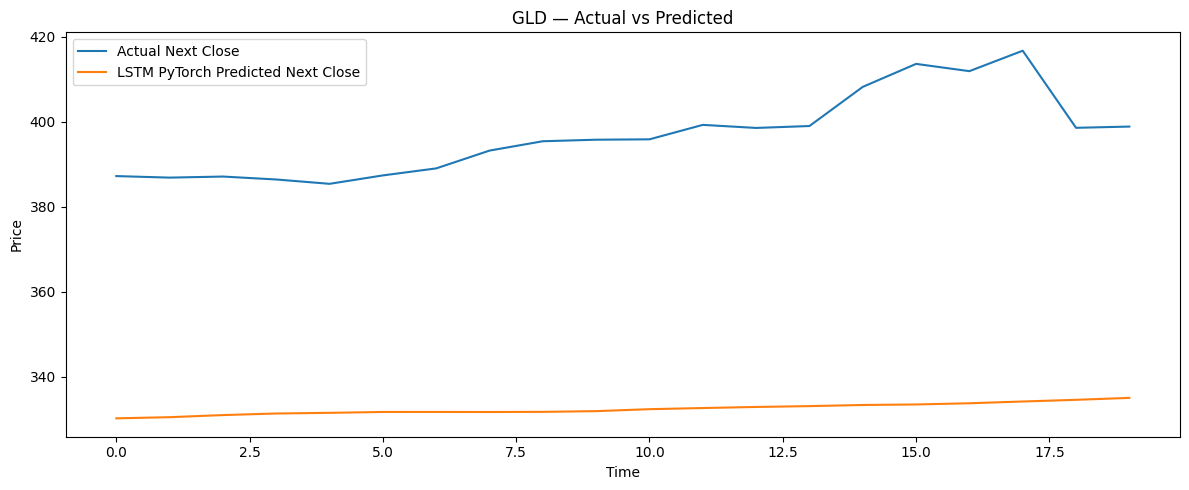

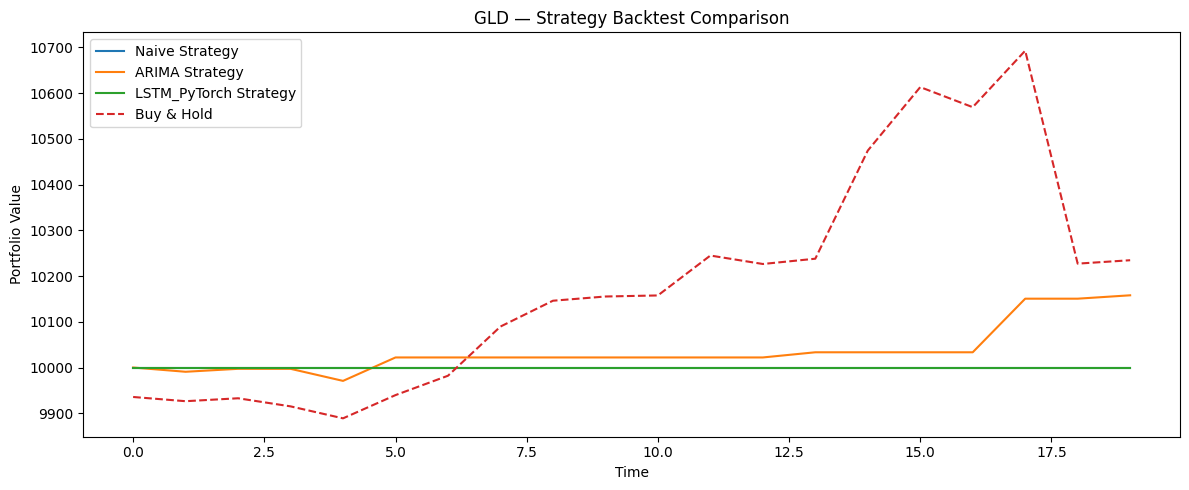

,Ticker,Model,RMSE,MAE,MAPE_%,Directional_Accuracy_%,Strategy_Return_%,BuyHold_Return_%,Sharpe_Ratio,Max_Drawdown_%
0,GLD,Naive,5.0929,2.9720,0.74,0.0,0.00,2.35,0.000,0.00
1,GLD,ARIMA,6.8990,4.7438,1.18,50.0,1.58,2.35,4.414,-0.29
2,GLD,LSTM_PyTorch,64.8270,64.2826,16.16,35.0,0.00,2.35,0.000,0.00


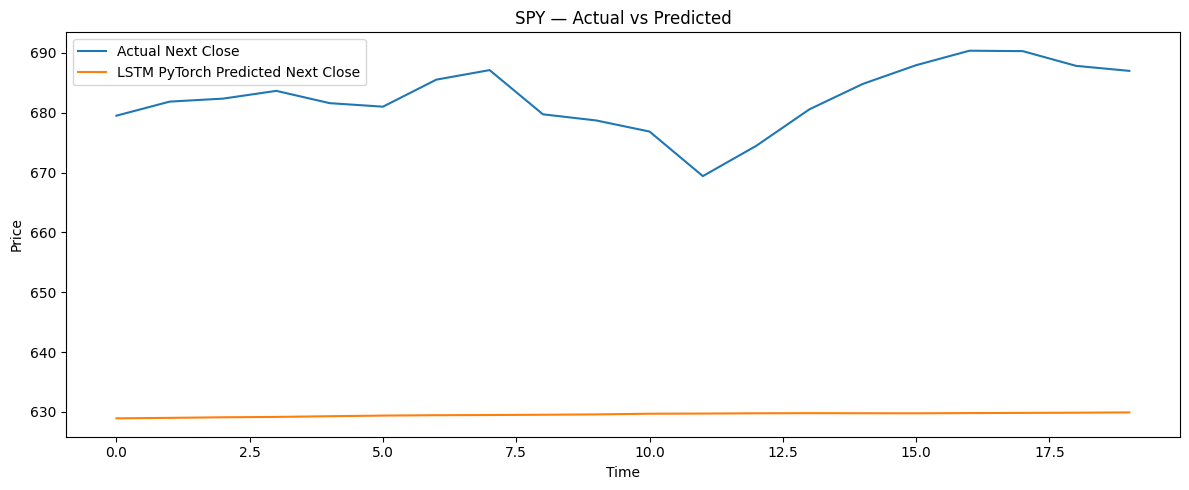

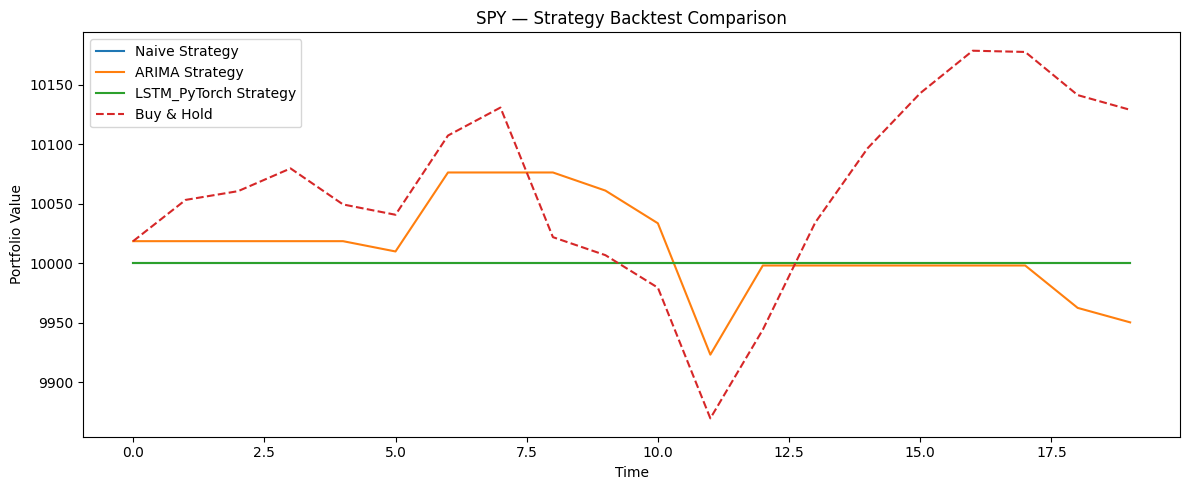

,Ticker,Model,RMSE,MAE,MAPE_%,Directional_Accuracy_%,Strategy_Return_%,BuyHold_Return_%,Sharpe_Ratio,Max_Drawdown_%
0,SPY,Naive,3.5667,2.8102,0.41,0.0,0.0,1.29,0.000,0.00
1,SPY,ARIMA,5.6284,4.7606,0.70,30.0,-0.5,1.29,-1.093,-1.52
2,SPY,LSTM_PyTorch,53.2418,52.9901,7.76,45.0,0.0,1.29,0.000,0.00


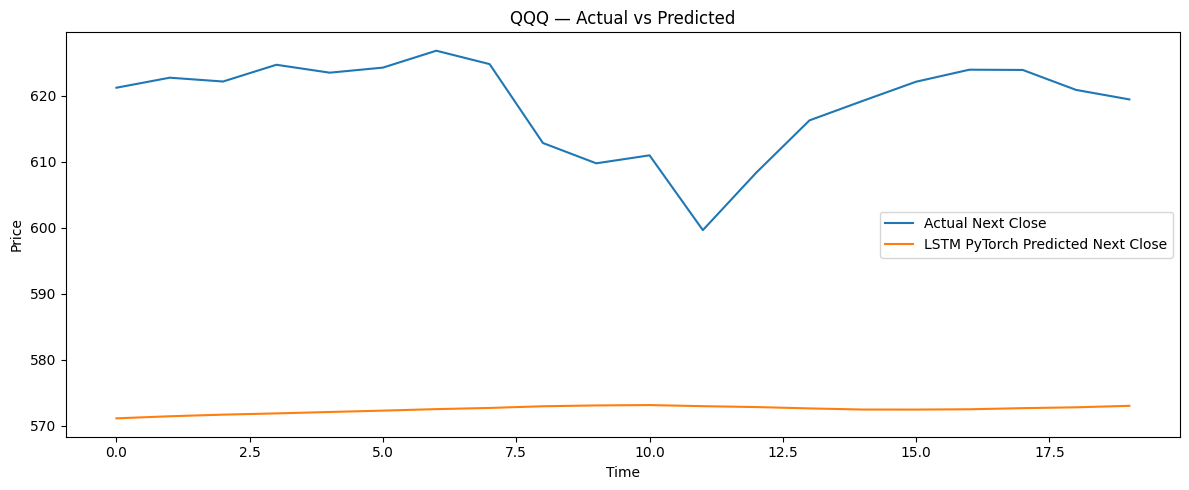

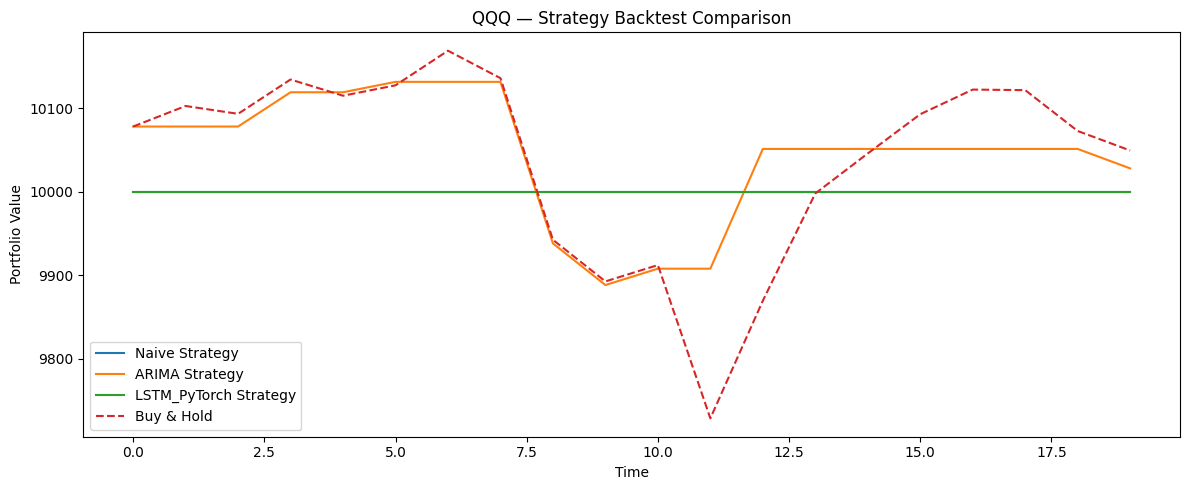

,Ticker,Model,RMSE,MAE,MAPE_%,Directional_Accuracy_%,Strategy_Return_%,BuyHold_Return_%,Sharpe_Ratio,Max_Drawdown_%
0,QQQ,Naive,4.9845,3.6178,0.59,0.0,0.00,0.5,0.000,0.0
1,QQQ,ARIMA,7.3784,5.5357,0.90,55.0,0.28,0.5,0.426,-2.4
2,QQQ,LSTM_PyTorch,46.9365,46.3828,7.48,45.0,0.00,0.5,0.000,0.0


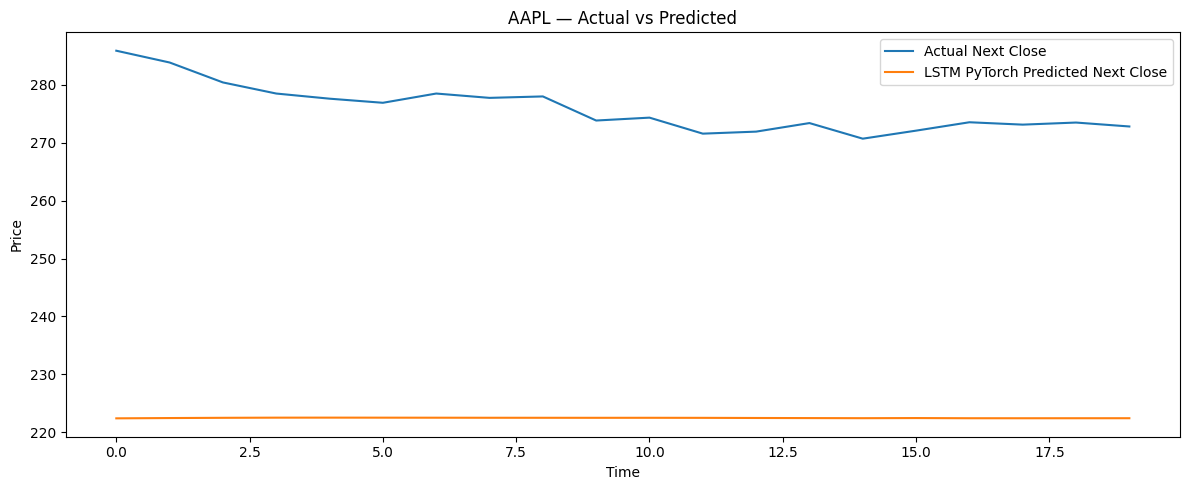

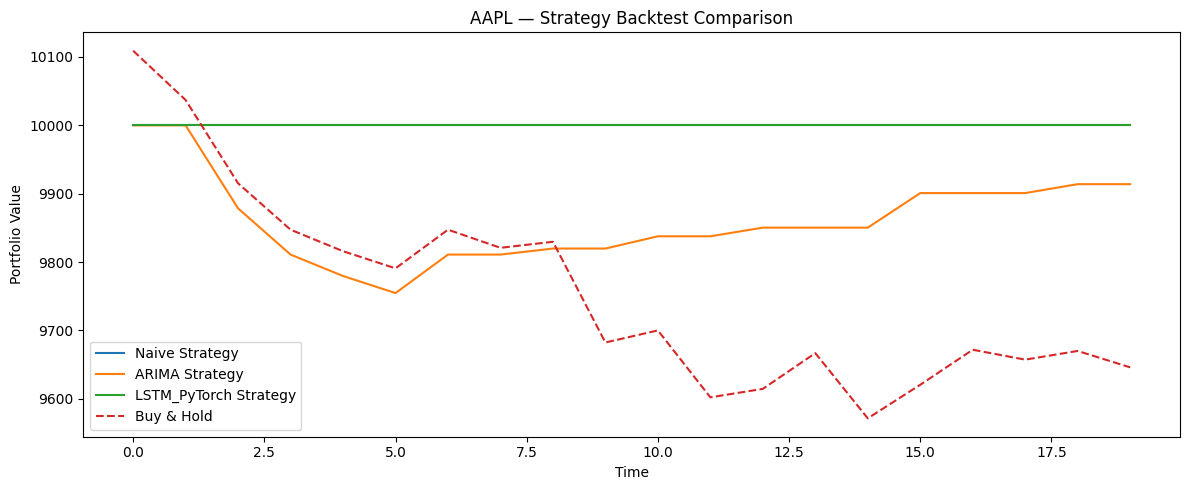

,Ticker,Model,RMSE,MAE,MAPE_%,Directional_Accuracy_%,Strategy_Return_%,BuyHold_Return_%,Sharpe_Ratio,Max_Drawdown_%
0,AAPL,Naive,1.9151,1.5466,0.56,0.0,0.00,-3.54,0.000,0.00
1,AAPL,ARIMA,3.0054,2.3226,0.84,65.0,-0.86,-3.54,-1.821,-2.45
2,AAPL,LSTM_PyTorch,53.6466,53.4944,19.37,55.0,0.00,-3.54,0.000,0.00


,Ticker,Model,RMSE,MAE,MAPE_%,Directional_Accuracy_%,Strategy_Return_%,BuyHold_Return_%,Sharpe_Ratio,Max_Drawdown_%
0,GLD,Naive,5.0929,2.9720,0.74,0.0,0.00,2.35,0.000,0.00
1,GLD,ARIMA,6.8990,4.7438,1.18,50.0,1.58,2.35,4.414,-0.29
2,GLD,LSTM_PyTorch,64.8270,64.2826,16.16,35.0,0.00,2.35,0.000,0.00
3,SPY,Naive,3.5667,2.8102,0.41,0.0,0.00,1.29,0.000,0.00
4,SPY,ARIMA,5.6284,4.7606,0.70,30.0,-0.50,1.29,-1.093,-1.52
5,SPY,LSTM_PyTorch,53.2418,52.9901,7.76,45.0,0.00,1.29,0.000,0.00
6,QQQ,Naive,4.9845,3.6178,0.59,0.0,0.00,0.50,0.000,0.00
7,QQQ,ARIMA,7.3784,5.5357,0.90,55.0,0.28,0.50,0.426,-2.40
8,QQQ,LSTM_PyTorch,46.9365,46.3828,7.48,45.0,0.00,0.50,0.000,0.00
9,AAPL,Naive,1.9151,1.5466,0.56,0.0,0.00,-3.54,0.000,0.00


In [10]:
all_results = []

for ticker in TICKERS:
    try:
        result = evaluate_ticker_pytorch(market_data, ticker)
        display(result)
        all_results.append(result)
    except Exception as e:
        print(f"Error for {ticker}: {e}")

final_results = pd.concat(all_results, ignore_index=True)
final_results

## Conclusion

This notebook compares statistical and deep learning methods for time-series asset forecasting and evaluates whether those forecasts translate into stronger backtested strategy performance.

**Potential next upgrades**
- Transformer-based time-series models
- Additional assets and asset allocation rules
- Macro or sentiment features
- Transaction cost modeling

## Reproducibility

- Data retrieval is automated via API
- Random seeds are fixed
- The notebook can be rerun end-to-end without external dataset files